In [1]:
import importlib
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

sys.path.append('../src')

import utils

importlib.reload(utils)

az.style.use('arviz-darkgrid')

plt.style.use('ggplot')

g++ not available, if using conda: `conda install gxx`


# Hierarchical Models

In the last notebook we built our first Bayesian model by borrowing a prior from a large external dataset. But often no such reference exists. This notebook tackles that case. We start with Empirical Bayes, which estimates the prior directly from a collection of groups, then turn it into a full hierarchical model, and finally step back to the question sitting underneath every model so far: where do the priors actually come from?

## Empirical Bayes

In the first model we were lucky. A big national dataset was sitting right there, so the prior was handed to us. But most of the time there is no such reference population to borrow from.

Empirical Bayes offers a way out. Instead of choosing the prior subjectively or borrowing it from outside, we estimate it from the data itself. The catch is that this only works when the data comes in groups. A single group cannot tell us how groups vary, but many groups can.

Say we no longer have the national survey. All we have is a handful of small cities, each with its own height sample, and some of them are tiny. Can we still build a prior? Yes, by assuming the cities all come from a shared country level distribution.

### The Setup: Many Small Groups

We can capture this with a two level structure.

For a single person in city $j$:

$x_{ij} \sim \mathcal{N}(\mu_j, \sigma^2)$

For the city averages themselves:

$\mu_j \sim \mathcal{N}(\mu_0, \tau^2)$

where

$\mu_j$ is the true average height in city $j$.

$\sigma$ is the person to person variation within a city.

$\mu_0$ is the overall average height across all cities.

$\tau$ is how much the cities differ from each other.

The second line is the key. It says the city averages are not scattered arbitrarily; they themselves follow a distribution centered on a common mean $\mu_0$. That shared distribution is the prior we are after, and we are going to read it off from the cities we observe.

**Example**

First, we will generate some city height data using a predefined country level distribution:

$\text{country mean height (CMH)} \sim \mathcal{N}(170, 5^2)$

Unlike the previous example, we will not give these parameters to the model, since they are only used to generate the data. While solving the problem we treat them as unknown.

$\text{city height} \sim \mathcal{N}(\text{CMH}, 12^2)$

$\text{sample sizes} = [220, 180, 60, 40, 25, 18, 12, 9, 8, 6]$

A few of them have a decent number of measurements, but most are small, and some are tiny. To keep the focus on the prior, we treat the within city spread $\sigma$ as known ($\sigma = 12$).

In [2]:
np.random.seed(42)

mu0_true = 170
tau_true = 5
sigma = 12

city_sample_sizes = np.array([220, 180, 60, 40, 25, 18, 12, 9, 8, 6])
n_cities = len(city_sample_sizes)

true_city_means = np.random.normal(mu0_true, tau_true, n_cities)

city_samples = [
    np.random.normal(mu, sigma, n)
    for mu, n in zip(true_city_means, city_sample_sizes)
]

city_means = np.array([sample.mean() for sample in city_samples])
city_se = sigma / np.sqrt(city_sample_sizes)

for j in range(n_cities):
    print(f"City {j + 1:2d}   n = {city_sample_sizes[j]:3d}   "
          f"sample mean = {city_means[j]:6.2f} cm   SE = {city_se[j]:.2f}")

City  1   n = 220   sample mean = 172.21 cm   SE = 0.81
City  2   n = 180   sample mean = 169.78 cm   SE = 0.89
City  3   n =  60   sample mean = 172.79 cm   SE = 1.55
City  4   n =  40   sample mean = 176.96 cm   SE = 1.90
City  5   n =  25   sample mean = 164.35 cm   SE = 2.40
City  6   n =  18   sample mean = 168.08 cm   SE = 2.83
City  7   n =  12   sample mean = 181.24 cm   SE = 3.46
City  8   n =   9   sample mean = 168.67 cm   SE = 4.00
City  9   n =   8   sample mean = 166.47 cm   SE = 4.24
City 10   n =   6   sample mean = 176.76 cm   SE = 4.90


### Estimating the Prior from the Groups

Now the actual Empirical Bayes step. We need the two prior parameters, $\mu_0$ and $\tau$, but don't have them. We only have the noisy city means. So we estimate them from those means, in the same way as the maximum likelihood step we did for the national data earlier, only now applied to the distribution of city averages.

For the overall mean we simply average the city means:

$\hat{\mu}_0 = \frac{1}{k}\sum_j \bar{x}_j$

For $\tau$ we have to be careful. The city means are spread out for two reasons:

* The cities genuinely differ ($\tau$).
* Each mean is measured with noise that shrinks as the sample grows ($SE_j = \sigma / \sqrt{n_j}$).

If we just took the variance of the city means, we would count the measurement noise as if it were real between city variation. We remove it by subtracting the average measurement variance:

$\hat{\tau}^2 = \text{Var}(\bar{x}_j) - \overline{SE_j^2}$

This is the part people most often get wrong the first time they learn Empirical Bayes, myself included.

If we instead pooled every person from every city and took its variance, we would be measuring the spread of individuals, which is dominated by the within city variation $\sigma$. That tells us how much people differ, not how much cities differ, so it does not reflect $\tau$.

In [3]:
mu0_hat = city_means.mean()
tau2_hat = max(0.0, city_means.var(ddof=1) - np.mean(city_se**2))
tau_hat = np.sqrt(tau2_hat)

print(f"estimated overall mean (mu0_hat):     {mu0_hat:.2f} cm")
print(f"estimated between city std (tau_hat): {tau_hat:.2f} cm")

estimated overall mean (mu0_hat):     171.73 cm
estimated between city std (tau_hat): 4.36 cm


The results are pretty close to the parameters that we used while generating the data.

### Shrinkage

Now that we have a prior, we combine it with each city's own data. For city $j$ we assign a weight to the prior using:

$w_j = \frac{SE_j^2}{\hat{\tau}^2 + SE_j^2}$

and then compute the posterior mean:

$\hat{\mu}_j = (1 - w_j)\bar{x}_j + w_j\hat{\mu}_0$

Intuitively, $w_j$ measures how big a city's own uncertainty is compared to the overall uncertainty. If $SE_j$ is small (a city with many measurements), the prior weight decreases and the estimate stays close to the city's own mean. If $SE_j$ is big (a tiny city), the prior is weighted more and the estimate is pulled toward the overall mean $\hat{\mu}_0$.

This pull is called shrinkage, since every city mean is shrunk toward the common center by an amount that depends on how trustworthy it is. The posterior also comes with its own standard deviation:

$\sigma_{\text{post}, j} = \sqrt{\dfrac{1}{\dfrac{1}{\hat{\tau}^2} + \dfrac{1}{SE_j^2}}}$

In [4]:
w = city_se**2 / (tau2_hat + city_se**2)
shrunk_means = (1 - w) * city_means + w * mu0_hat
posterior_std = np.sqrt(1 / (1 / tau2_hat + 1 / city_se**2))

for j in range(n_cities):
    print(f"City {j + 1:2d}   n = {city_sample_sizes[j]:3d}   "
          f"raw = {city_means[j]:6.2f}   w = {w[j]:.2f}   "
          f"shrunk = {shrunk_means[j]:6.2f}   post sd = {posterior_std[j]:.2f}")

City  1   n = 220   raw = 172.21   w = 0.03   shrunk = 172.19   post sd = 0.80
City  2   n = 180   raw = 169.78   w = 0.04   shrunk = 169.86   post sd = 0.88
City  3   n =  60   raw = 172.79   w = 0.11   shrunk = 172.67   post sd = 1.46
City  4   n =  40   raw = 176.96   w = 0.16   shrunk = 176.13   post sd = 1.74
City  5   n =  25   raw = 164.35   w = 0.23   shrunk = 166.07   post sd = 2.10
City  6   n =  18   raw = 168.08   w = 0.30   shrunk = 169.16   post sd = 2.37
City  7   n =  12   raw = 181.24   w = 0.39   shrunk = 177.56   post sd = 2.71
City  8   n =   9   raw = 168.67   w = 0.46   shrunk = 170.07   post sd = 2.95
City  9   n =   8   raw = 166.47   w = 0.49   shrunk = 169.03   post sd = 3.04
City 10   n =   6   raw = 176.76   w = 0.56   shrunk = 173.95   post sd = 3.26


City 10 has the lowest sample size, hence its prior weight is the largest ($w = 0.56$). As a natural consequence of that, it shrank the most toward the overall mean.

C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_16388\888141926.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


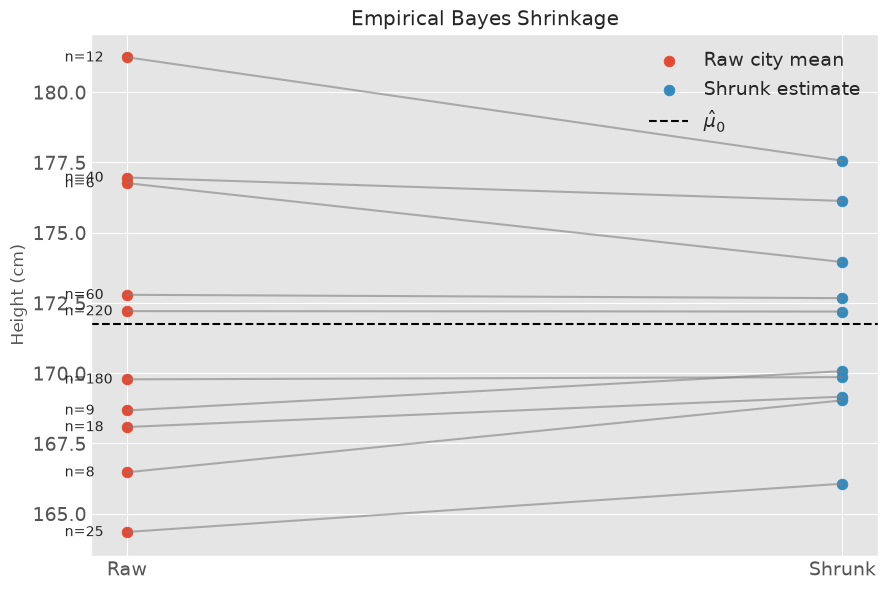

In [5]:
order = np.argsort(city_sample_sizes)

fig, ax = plt.subplots(figsize=(9, 6))
for j in order:
    ax.plot([0, 1], [city_means[j], shrunk_means[j]], color="grey", alpha=0.6)
ax.scatter(np.zeros(n_cities), city_means, s=60, label="Raw city mean")
ax.scatter(np.ones(n_cities), shrunk_means, s=60, label="Shrunk estimate")
ax.axhline(mu0_hat, linestyle="--", color="black", label=r"$\hat{\mu}_0$")

for j in order:
    ax.annotate(f"n={city_sample_sizes[j]}", (0, city_means[j]),
                textcoords="offset points", xytext=(-45, -3))

ax.set_xticks([0, 1])
ax.set_xticklabels(["Raw", "Shrunk"])
ax.set_ylabel("Height (cm)")
ax.set_title("Empirical Bayes Shrinkage")
ax.legend()
plt.tight_layout()
plt.show()

The tiny cities moved a lot, while the big ones barely budged. That is Empirical Bayes doing its job: it trusts the well measured cities and rescues the poorly measured ones by borrowing strength from the rest.

Notice that we never had to invent a prior by hand. We read it straight off the data, which is exactly what makes this approach empirical.

Empirical Bayes did this in two steps: first it estimated the prior, then it shrank the cities toward it. The next section turns this into a single model that does both at once.

## Incorporating Uncertainty into a Bayesian Model

We just did Empirical Bayes in two steps. First we estimated the prior parameters $\mu_0$ and $\tau$ from the city means, then we plugged them in and shrank each city toward the center. This works, but it quietly pretends that our estimated prior is the exact truth. In reality we are not sure about $\mu_0$ and $\tau$ either, since we estimated them from a handful of noisy cities.

The fully Bayesian version fixes this. Instead of estimating the prior first and the cities second, it puts a prior on everything and lets the data settle all of them at once. This way the uncertainty about $\mu_0$ and $\tau$ flows naturally into the city estimates.

We will work on the same example again, but this time we place priors on the top level parameters as well:

$\mu_0 \sim \mathcal{N}(170, 10^2)$ (instead of the fixed 171 we plugged in before)

$\tau \sim \text{HalfNormal}(10)$ (instead of the fixed 4.36 we plugged in before)

$\mu_j \sim \mathcal{N}(\mu_0, \tau^2)$

$x_{ij} \sim \mathcal{N}(\mu_j, \sigma^2)$

We keep the within city spread $\sigma$ fixed at the value we used before, so the only new pieces are the priors we place on $\mu_0$ and $\tau$.

In [6]:
np.random.seed(42)

mu0_true = 170
tau_true = 5
sigma = 12

city_sample_sizes = np.array([220, 180, 60, 40, 25, 18, 12, 9, 8, 6])
n_cities = len(city_sample_sizes)

true_city_means = np.random.normal(mu0_true, tau_true, n_cities)
city_samples = [
    np.random.normal(mu, sigma, size)
    for mu, size in zip(true_city_means, city_sample_sizes)
]

city_means = np.array([sample.mean() for sample in city_samples])
city_idx = np.repeat(np.arange(n_cities), city_sample_sizes)
all_heights = np.concatenate(city_samples)

with pm.Model() as hierarchical_model:
    mu0 = pm.Normal("mu0", mu=170, sigma=10)
    tau = pm.HalfNormal("tau", sigma=10)

    city_mean = pm.Normal("city_mean", mu=mu0, sigma=tau, shape=n_cities)
    obs = pm.Normal("obs", mu=city_mean[city_idx], sigma=sigma, observed=all_heights)

    hierarchical_trace = pm.sample(2000, tune=1000, chains=2, target_accept=0.95, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu0, tau, city_mean]


c:\Users\egemen.u.dalgic\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Let's compare the three estimates side by side:

* The raw city mean 
* The two step Empirical Bayes estimate
* The hierarchical posterior mean.


In [7]:
city_se = sigma / np.sqrt(city_sample_sizes)
mu0_hat = city_means.mean()
tau2_hat = max(0.0, city_means.var(ddof=1) - np.mean(city_se**2))
w = city_se**2 / (tau2_hat + city_se**2)
eb_means = (1 - w) * city_means + w * mu0_hat

hier_means = hierarchical_trace.posterior["city_mean"].mean(("chain", "draw")).values

comparison = pd.DataFrame({
    "n": city_sample_sizes,
    "raw": city_means,
    "empirical_bayes": eb_means,
    "hierarchical": hier_means,
}).round(2)

print(f"posterior mu0: {hierarchical_trace.posterior['mu0'].mean().item():.2f} "
      f"(sd {hierarchical_trace.posterior['mu0'].std().item():.2f})")
print(f"posterior tau: {hierarchical_trace.posterior['tau'].mean().item():.2f} "
      f"(sd {hierarchical_trace.posterior['tau'].std().item():.2f})")
comparison


posterior mu0: 171.65 (sd 1.73)
posterior tau: 4.63 (sd 1.80)


,n,raw,empirical_bayes,hierarchical
0,220,172.21,172.19,172.19
1,180,169.78,169.86,169.89
2,60,172.79,172.67,172.63
3,40,176.96,176.13,175.99
4,25,164.35,166.07,166.21
5,18,168.08,169.16,169.25
6,12,181.24,177.56,177.41
7,9,168.67,170.07,170.02
8,8,166.47,169.03,168.99
9,6,176.76,173.95,173.90


The hierarchical estimates are very close to the Empirical Bayes ones, which is nice. The difference is that here the prior was not fixed in advance. Which one is the more correct approach? It depends.

* Empirical Bayes is more computationally efficient, but it reduces some uncertainties to a single number, which makes it less reliable.

* The full Bayesian model is computationally demanding due to the posterior sampling procedure, but it gives more honest results since it does not reduce the prior parameters to a single number.

This idea of stacking priors in layers is the backbone of modern Bayesian modeling, and we will lean on it again when we test hypotheses and build regressions.

## Choosing Priors

In the model above we quietly placed a broad normal on $\mu_0$ and a half normal on $\tau$. Where do such choices come from? Every Bayesian model needs priors, and how much they influence the result depends on these factors:

* **Distribution structure:** For example, keeping everything else equal, selecting a normal distribution as a prior instead of a Student-t distribution forces the posterior parameter to stay more within the specified range, due to the shorter tails it has.

* **The data quantity:** As we saw in the conjugate definitions, a parameter is pulled more toward the data when the data quantity is large. For instance, sample sizes of 10 and 10,000 have a very different impact on the posterior.

We cannot control the data quantity, but we can decide what the priors look like. That is what we will focus on in this section.

### Noninformative Priors

When we have absolutely no idea about the event we are focusing on, we use a noninformative (or flat) prior. It tries to say as little as possible and lets the data shape the model. A uniform distribution over a reasonable range is one of the simplest examples.

It sounds safe, but uninformative priors have downsides. When data is not abundant, uninformative priors can produce unstable or even improper posteriors. When there is not enough data and the prior is not helping to shape the posterior, this is a natural consequence.

On top of that, as we saw before, we frequently transform our data, and a prior that is flat on one scale is not flat after a transformation. So a uniform prior can lose its uninformative structure once we change the scale:

C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_16388\1200613384.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


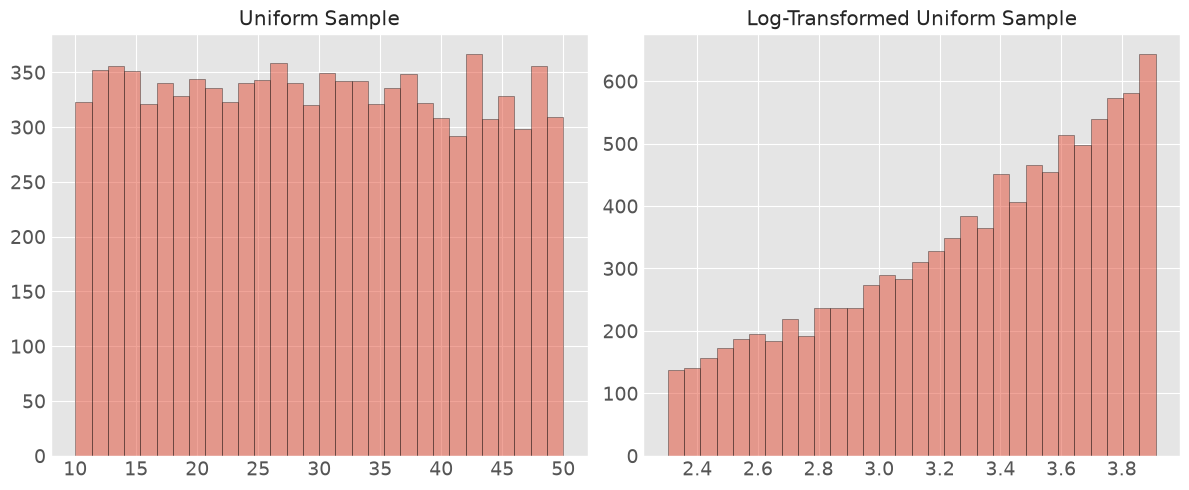

In [8]:
np.random.seed(42)
uniform_sample = np.random.uniform(10,50,10000)
log_uniform_sample = np.log(uniform_sample)

fig,ax = plt.subplots(1,2,figsize=(12,5))
ax[0].hist(uniform_sample, bins=30, edgecolor='black',alpha = 0.5)
ax[0].set_title('Uniform Sample')
ax[1].hist(log_uniform_sample, bins=30, edgecolor='black',alpha = 0.5)
ax[1].set_title('Log-Transformed Uniform Sample')   
plt.tight_layout()
plt.show()

To combat this problem, we can use the Jeffreys prior, which stays invariant under reparameterization.

### Weakly Informative Priors

When we have a rough idea about the posterior, we can use weakly informative priors. This is especially handy to eliminate anomaly conditions. Our $\text{HalfNormal}(10)$ on $\tau$ is a good example. It says the cities probably do not differ by hundreds of centimeters, without committing to any specific value.


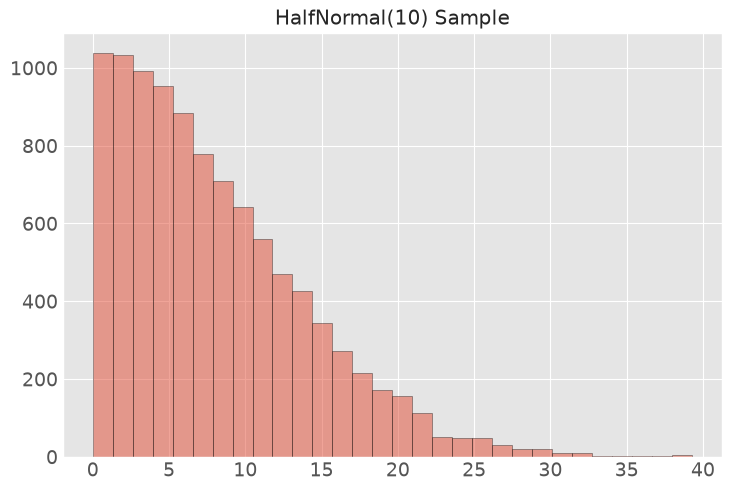

In [9]:
np.random.seed(42)
halfnormal_sample = np.abs(np.random.normal(0, 10, 10000))

plt.figure()
plt.hist(halfnormal_sample, bins=30, edgecolor='black', alpha=0.5)
plt.title('HalfNormal(10) Sample')
plt.show()

### Informative Priors

An informative prior incorporates real knowledge into the model, usually from previous studies or expert judgment. The national height distribution we used as a prior in the first notebook was informative. These are most valuable exactly when data is scarce and reliable outside knowledge exists. But using informative priors can be risky. When an informative prior is wrongly defined, it can distort the outcomes, especially when the data is not sufficient to pull model parameters towards real values.


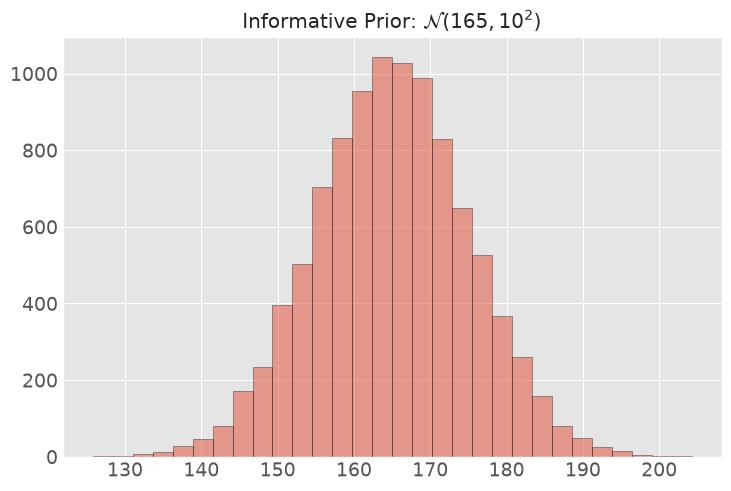

In [10]:
np.random.seed(42)
informative_sample = np.random.normal(165, 10, 10000)

plt.figure()
plt.hist(informative_sample, bins=30, edgecolor='black', alpha=0.5)
plt.title(r'Informative Prior: $\mathcal{N}(165, 10^2)$')
plt.show()

## Prior Distributions in Practice

Knowing the three categories is one thing; picking an actual distribution is another. The choice usually follows the kind of parameter we are modeling.

* For a location parameter such as a mean, a normal prior is the everyday choice. When we worry that the true value might be surprisingly far from our guess, a Student-t or a Cauchy prior is safer, since their heavy tails let the data pull the estimate out to extreme values without a fight. The Cauchy is just a Student-t with one degree of freedom, the heaviest tail of the family.

* For a scale parameter such as a standard deviation, the prior must stay positive. The usual weakly informative choices are the HalfNormal and the HalfCauchy, the latter being popular for the group level spread $\tau$ in hierarchical models. The older Inverse-Gamma prior is still seen but is now discouraged because it behaves badly when the true scale is near zero.

* For a probability, the Beta distribution is the natural prior, which is exactly the conjugate partner we used for the Beta-Binomial model.

* One more prior is worth naming here because we will meet it in the next notebook. The Jeffreys-Zellner-Siow (JZS) prior places a Cauchy on the effect size and is a common default for Bayesian hypothesis testing, precisely because its heavy tails make it robust to prior misspecification.

## Prior Predictive Checks

All of this can feel abstract. A practical way to judge a prior is to forget the data for a moment and ask what kind of datasets the prior alone considers possible. We sample parameters from the prior, generate fake observations from them, and see if those observations look reasonable. If the prior implies impossible heights or wildly unrealistic spreads, it needs rethinking.

`pymc` makes this easy with `pm.sample_prior_predictive`. Let's check the weakly informative priors we used for the height model.

Sampling: [height, mu, sigma_height]


prior predictive middle 95%: 142.6 to 198.2 cm


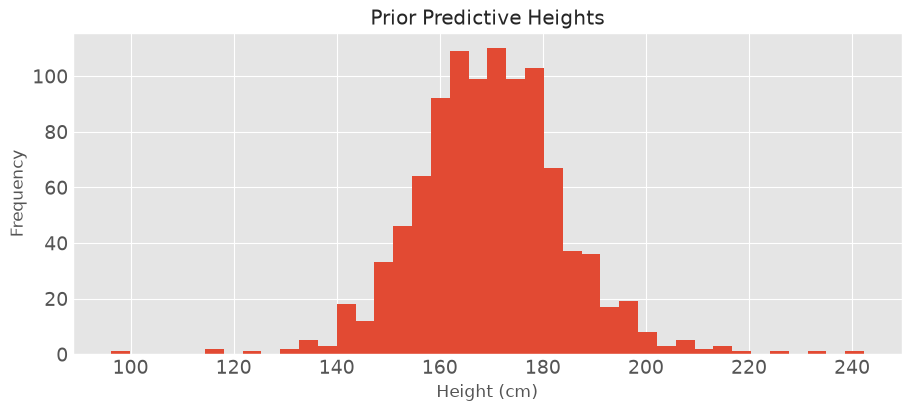

In [11]:
with pm.Model() as prior_check_model:
    mu = pm.Normal("mu", mu=170, sigma=10)
    sigma_height = pm.HalfNormal("sigma_height", sigma=10)
    height = pm.Normal("height", mu=mu, sigma=sigma_height)

    prior_samples = pm.sample_prior_predictive(draws=1000, random_seed=42)

prior_heights = prior_samples.prior["height"].values.flatten()

print(f"prior predictive middle 95%: "
      f"{np.percentile(prior_heights, 2.5):.1f} to {np.percentile(prior_heights, 97.5):.1f} cm")

plt.figure(figsize=(9, 4))
plt.hist(prior_heights, bins=40)
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.title("Prior Predictive Heights")
plt.show()

The sampled heights are in a plausible range, so we can conclude that priors are reasonable. If instead we had seen negative heights or values in the thousands, that would be a clear sign to tighten them.

With priors understood and checked, we now have every piece of a Bayesian model in place: a likelihood, a sensible prior, and a way to compute the posterior. In the next notebook we put these to work on hypothesis testing, where the choice of prior becomes central and the JZS prior we just met takes the stage.